In [3]:
# Sprint 1 - Python Foundations
# Industrial AI & ML Learning Project

print("Sprint 1 is live!")
print("Learning Python for Industrial AI")

Sprint 1 is live!
Learning Python for Industrial AI


In [4]:
# Variables - storing information
station_name = "Paris Nord CNG"
station_id = 12
inlet_pressure = 187.5      # bar
temperature = 42.3          # degrees Celcius
compressor_running = True

print(station_name)
print(station_id)
print(inlet_pressure)
print(temperature)
print(compressor_running)

Paris Nord CNG
12
187.5
42.3
True


In [5]:
# Checking variable types
print(type(station_name))
print(type(station_id))
print(type(inlet_pressure))
print(type(compressor_running))

<class 'str'>
<class 'int'>
<class 'float'>
<class 'bool'>


In [6]:
# Lists - storing multiple values
station_ids = [1, 2, 3, 4, 5, 12, 17, 23]
pressures = [182.3, 187.5, 191.2, 178.9, 185.0]
station_names = ["Paris Nord", "Brussels Sud", "Amsterdam West", "Lyon Est"]

# Access individual items by position (starting from 0)
print(station_names[0])     # first item
print(station_names[1])     # second item
print(station_names[-1])    # last item

# How many items in the list
print(len(pressures))

Paris Nord
Brussels Sud
Lyon Est
5


In [7]:
# Loop through pressures and flag any out of normal range
# Normal operating range for CNG inlet: 180 - 200 bar
pressures = [182.3, 187.5, 201.2, 178.9, 185]

for pressure in pressures:
    if pressure > 200:
        print(f"HIGH ALARM: {pressure} bar")
    elif pressure < 180:
        print(f"LOW ALARM: {pressure} bar")
    else:
        print(f"Normal: {pressure} bar")

Normal: 182.3 bar
Normal: 187.5 bar
HIGH ALARM: 201.2 bar
LOW ALARM: 178.9 bar
Normal: 185 bar


In [8]:
# A reusable alarm checker function
def check_pressure(pressure, station_name, low_limit=180, high_limit=200):
    """
    Check if a pressure reading is within acceptable limits.
    Returns the alarm status as a string
    """
    if pressure > high_limit:
        return f"HIGH ALARM: {station_name} at {pressure} bar"
    elif pressure < low_limit:
        return f"LOW ALARM: {station_name} at {pressure} bar"
    else:
        return f"OK: {station_name} at {pressure} bar"

# Now we can reuse it for any station
print(check_pressure(187.5, "Paris Nord"))
print(check_pressure(201.2, "Brussels Sud"))
print(check_pressure(178.9, "Amsterdam West"))

# The limits are optional - we can override them for different equipment
print(check_pressure(178.9, "Lyon Est", low_limit=175, high_limit=210))

OK: Paris Nord at 187.5 bar
HIGH ALARM: Brussels Sud at 201.2 bar
LOW ALARM: Amsterdam West at 178.9 bar
OK: Lyon Est at 178.9 bar


In [9]:
import pandas as pd

# Create a DataFrame - think of it as a table, like your Insights Hub mapping table
data = {
    "station_name": ["Paris Nord", "Brussels Sud", "Amsterdam West", "Lyon Est", "Bordeaux"],
    "station_id": [1, 2, 3, 4, 5],
    "inlet_pressure": [182.3, 201.2, 178.9, 187.5, 185.0],
    "temperature": [42.3, 38.1, 51.2, 44.7, 39.8],
    "compressor_running": [True, True, False, True, True]
}

df = pd.DataFrame(data)
print(df)


     station_name  station_id  inlet_pressure  temperature  compressor_running
0      Paris Nord           1           182.3         42.3                True
1    Brussels Sud           2           201.2         38.1                True
2  Amsterdam West           3           178.9         51.2               False
3        Lyon Est           4           187.5         44.7                True
4        Bordeaux           5           185.0         39.8                True


In [10]:
# The first things you always do with a new dataset

# How big is it?
print(df.shape)

# What are the column names and data types?
print(df.dtypes)

# Statistical summary of numeric columns
print(df.describe())

(5, 5)
station_name              str
station_id              int64
inlet_pressure        float64
temperature           float64
compressor_running       bool
dtype: object
       station_id  inlet_pressure  temperature
count    5.000000        5.000000     5.000000
mean     3.000000      186.980000    43.220000
std      1.581139        8.567205     5.114391
min      1.000000      178.900000    38.100000
25%      2.000000      182.300000    39.800000
50%      3.000000      185.000000    42.300000
75%      4.000000      187.500000    44.700000
max      5.000000      201.200000    51.200000


In [11]:
# Show only stations with high pressure
high_pressure = df[df["inlet_pressure"] > 190]
print(high_pressure)

# Show only stations where compressor is running
running = df[df["compressor_running"] == True]
print(running)

# Show station with high temp AND compressor running
hot_and_running = df[(df["temperature"] > 40) & (df["compressor_running"] == True)]
print(hot_and_running)

   station_name  station_id  inlet_pressure  temperature  compressor_running
1  Brussels Sud           2           201.2         38.1                True
   station_name  station_id  inlet_pressure  temperature  compressor_running
0    Paris Nord           1           182.3         42.3                True
1  Brussels Sud           2           201.2         38.1                True
3      Lyon Est           4           187.5         44.7                True
4      Bordeaux           5           185.0         39.8                True
  station_name  station_id  inlet_pressure  temperature  compressor_running
0   Paris Nord           1           182.3         42.3                True
3     Lyon Est           4           187.5         44.7                True


In [12]:
# Apply our alarm function to every rown in the DataFrame
df["alarm_status"] = df.apply(
    lambda row: check_pressure(row["inlet_pressure"], row["station_name"]),
    axis=1
)

print(df[["station_name", "inlet_pressure", "alarm_status"]])

     station_name  inlet_pressure                            alarm_status
0      Paris Nord           182.3             OK: Paris Nord at 182.3 bar
1    Brussels Sud           201.2   HIGH ALARM: Brussels Sud at 201.2 bar
2  Amsterdam West           178.9  LOW ALARM: Amsterdam West at 178.9 bar
3        Lyon Est           187.5               OK: Lyon Est at 187.5 bar
4        Bordeaux           185.0               OK: Bordeaux at 185.0 bar


In [13]:
import pandas as pd

# Our CNG station fleet
data = {
    "station_name": ["Paris Nord", "Brussels Sud", "Amsterdam West", "Lyon Est", "Bordeaux"],
    "station_id": [1, 2, 3, 4, 5],
    "inlet_pressure": [182.3, 201.2, 178.9, 187.5, 185.0],
    "temperature": [42.3, 38.1, 51.2, 44.7, 39.8],
    "compressor_running": [True, True, False, True, True]
}

df = pd.DataFrame(data)
df

,station_name,station_id,inlet_pressure,temperature,compressor_running
0,Paris Nord,1,182.3,42.3,True
1,Brussels Sud,2,201.2,38.1,True
2,Amsterdam West,3,178.9,51.2,False
3,Lyon Est,4,187.5,44.7,True
4,Bordeaux,5,185.0,39.8,True


In [14]:
# A simple dictionary
station = {
    "name": "Paris Nord",
    "pressure": 182.3,
    "running": True
}

# Access a value by its key
print(station["name"])
print(station["pressure"])

Paris Nord
182.3


In [15]:
# Accessing a single column from a DataFrame
# uses the same square bracket syntax as a dictionary!
print(df["station_name"])

0        Paris Nord
1      Brussels Sud
2    Amsterdam West
3          Lyon Est
4          Bordeaux
Name: station_name, dtype: str


In [16]:
# Single column - returns a Series
print(df["inlet_pressure"])
print("---")

0    182.3
1    201.2
2    178.9
3    187.5
4    185.0
Name: inlet_pressure, dtype: float64
---


In [17]:
# Multiple columns - returns a DataFrame
print(df[["station_name", "inlet_pressure"]])
print("---")

     station_name  inlet_pressure
0      Paris Nord           182.3
1    Brussels Sud           201.2
2  Amsterdam West           178.9
3        Lyon Est           187.5
4        Bordeaux           185.0
---


In [18]:
# Single row by position
print(df.iloc[0])

station_name          Paris Nord
station_id                     1
inlet_pressure             182.3
temperature                 42.3
compressor_running          True
Name: 0, dtype: object


In [19]:
single = df["inlet_pressure"]
multi = df[["station_name", "inlet_pressure"]]

print(type(single))
print(type(multi))

<class 'pandas.Series'>
<class 'pandas.DataFrame'>


In [20]:
# Adding a new column - pressure in PSI (1 bar = 14.5038 psi)
df["inlet_pressure_psi"] = df["inlet_pressure"] * 14.5038

# Adding a column based on a condition
df["pressure_ok"] = (df["inlet_pressure"] >= 180) & (df["inlet_pressure"] <= 200)

print(df[["station_name", "inlet_pressure", "inlet_pressure_psi", "pressure_ok"]])

     station_name  inlet_pressure  inlet_pressure_psi  pressure_ok
0      Paris Nord           182.3          2644.04274         True
1    Brussels Sud           201.2          2918.16456        False
2  Amsterdam West           178.9          2594.72982        False
3        Lyon Est           187.5          2719.46250         True
4        Bordeaux           185.0          2683.20300         True


In [21]:
# Update a single value
# .loc means "locate by label" - [row, column]
df.loc[1, "inlet_pressure"] = 192.5

# Recalculate the PSI column now the pressure has changed
df["inlet_pressure_psi"] = df["inlet_pressure"] * 14.5038

# Recalculate pressure_ok
df["pressure_ok"] = (df["inlet_pressure"] >= 180) & (df["inlet_pressure"] <= 200)

print(df[["station_name", "inlet_pressure", "inlet_pressure_psi", "pressure_ok"]])

     station_name  inlet_pressure  inlet_pressure_psi  pressure_ok
0      Paris Nord           182.3          2644.04274         True
1    Brussels Sud           192.5          2791.98150         True
2  Amsterdam West           178.9          2594.72982        False
3        Lyon Est           187.5          2719.46250         True
4        Bordeaux           185.0          2683.20300         True


In [22]:
# Update only Brussels Sud's PSI and pressure_ok - not the whole column
df.loc[1, "inlet_pressure_psi"] = df.loc[1, "inlet_pressure"] * 14.5038
df.loc[1, "pressure_ok"] = (df.loc[1, "inlet_pressure"] >= 180) & (df.loc[1, "inlet_pressure"] <= 200)

print(df[["station_name", "inlet_pressure", "inlet_pressure_psi", "pressure_ok"]])

     station_name  inlet_pressure  inlet_pressure_psi  pressure_ok
0      Paris Nord           182.3          2644.04274         True
1    Brussels Sud           192.5          2791.98150         True
2  Amsterdam West           178.9          2594.72982        False
3        Lyon Est           187.5          2719.46250         True
4        Bordeaux           185.0          2683.20300         True


In [23]:
# A simple function
def check_pressure(pressure, station_name):
    if pressure > 200:
        return f"HIGH ALARM: {station_name}"
    elif pressure < 180:
        return f"LOW ALARM: {station_name}"
    else:
        return f"OK: {station_name}"

# Apply it to every row
df["alarm_status"] = df.apply(
    lambda row: check_pressure(row["inlet_pressure"], row["station_name"]),
    axis=1
)

print(df[["station_name", "inlet_pressure", "alarm_status"]])

     station_name  inlet_pressure               alarm_status
0      Paris Nord           182.3             OK: Paris Nord
1    Brussels Sud           192.5           OK: Brussels Sud
2  Amsterdam West           178.9  LOW ALARM: Amsterdam West
3        Lyon Est           187.5               OK: Lyon Est
4        Bordeaux           185.0               OK: Bordeaux


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style - makes plots look clean and professional
sns.set_theme(style="darkgrid")

print("Plotting libraries ready")

Plotting libraries ready


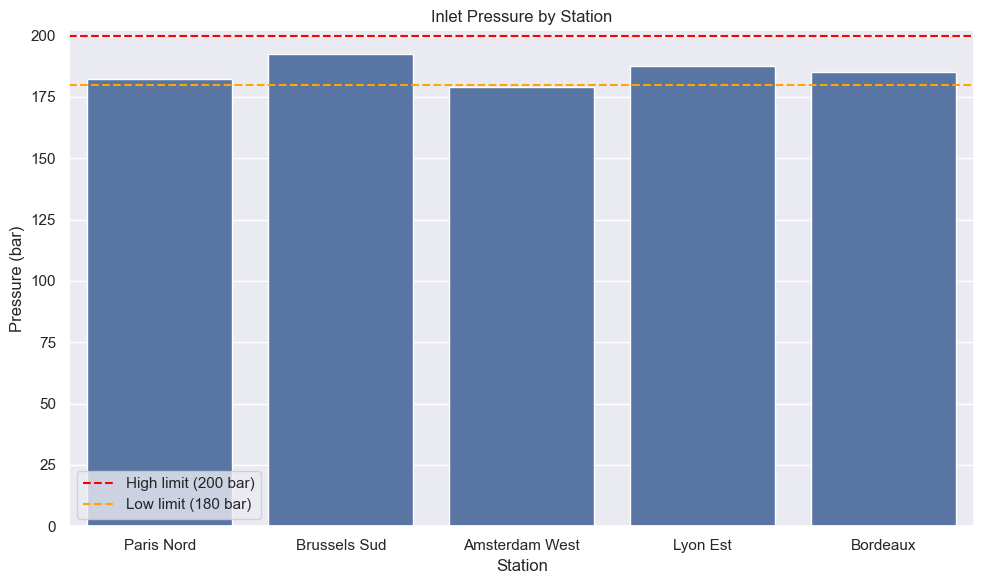

In [25]:
# Bar chart of inlet pressure per station
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x="station_name", y="inlet_pressure")

# Add reference lines for alarm limits
plt.axhline(y=200, color="red", linestyle="--", label="High limit (200 bar)")
plt.axhline(y=180, color="orange", linestyle="--", label="Low limit (180 bar)")

# Labels and title
plt.title("Inlet Pressure by Station")
plt.xlabel("Station")
plt.ylabel("Pressure (bar)")
plt.legend()
plt.tight_layout()
plt.show()

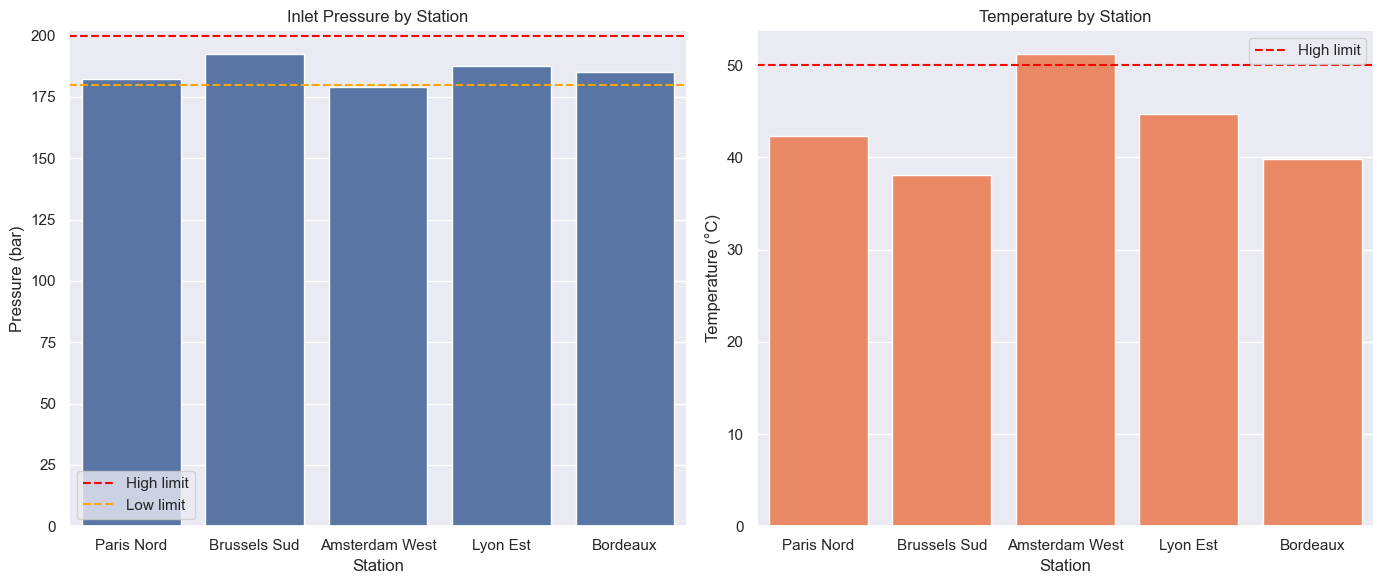

In [26]:
# Side by side comparison of pressure and temperature
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Pressure chart on the left
sns.barplot(data=df, x="station_name", y="inlet_pressure", ax=ax1)
ax1.axhline(y=200, color="red", linestyle="--", label="High limit")
ax1.axhline(y=180, color="orange", linestyle="--", label="Low limit")
ax1.set_title("Inlet Pressure by Station")
ax1.set_xlabel("Station")
ax1.set_ylabel("Pressure (bar)")
ax1.legend()

# Temperature chart on the right
sns.barplot(data=df, x="station_name", y="temperature", ax=ax2, color="coral")
ax2.axhline(y=50, color="red", linestyle="--", label="High limit")
ax2.set_title("Temperature by Station")
ax2.set_xlabel("Station")
ax2.set_ylabel("Temperature (°C)")
ax2.legend()

plt.tight_layout()
plt.show()

In [27]:
import numpy as np
import pandas as pd

# Simulate 24 hours of pressure readings at 1 reading per hour
# for Paris Nord CNG station
np.random.seed(42)  # makes random numbers reproducible

hours = pd.date_range(start="2024-01-15 00:00", periods=24, freq="h")
pressure = 185 + np.random.normal(0, 3, 24)  # mean 185 bar, std of 3

# Inject a fault - pressure drops at hour 14
pressure[14] = 171.2
pressure[15] = 168.5
pressure[16] = 172.1

ts_df = pd.DataFrame({
    "timestamp": hours,
    "pressure": pressure
})

print(ts_df)

             timestamp    pressure
0  2024-01-15 00:00:00  186.490142
1  2024-01-15 01:00:00  184.585207
2  2024-01-15 02:00:00  186.943066
3  2024-01-15 03:00:00  189.569090
4  2024-01-15 04:00:00  184.297540
5  2024-01-15 05:00:00  184.297589
6  2024-01-15 06:00:00  189.737638
7  2024-01-15 07:00:00  187.302304
8  2024-01-15 08:00:00  183.591577
9  2024-01-15 09:00:00  186.627680
10 2024-01-15 10:00:00  183.609747
11 2024-01-15 11:00:00  183.602811
12 2024-01-15 12:00:00  185.725887
13 2024-01-15 13:00:00  179.260159
14 2024-01-15 14:00:00  171.200000
15 2024-01-15 15:00:00  168.500000
16 2024-01-15 16:00:00  172.100000
17 2024-01-15 17:00:00  185.942742
18 2024-01-15 18:00:00  182.275928
19 2024-01-15 19:00:00  180.763089
20 2024-01-15 20:00:00  189.396946
21 2024-01-15 21:00:00  184.322671
22 2024-01-15 22:00:00  185.202585
23 2024-01-15 23:00:00  180.725755


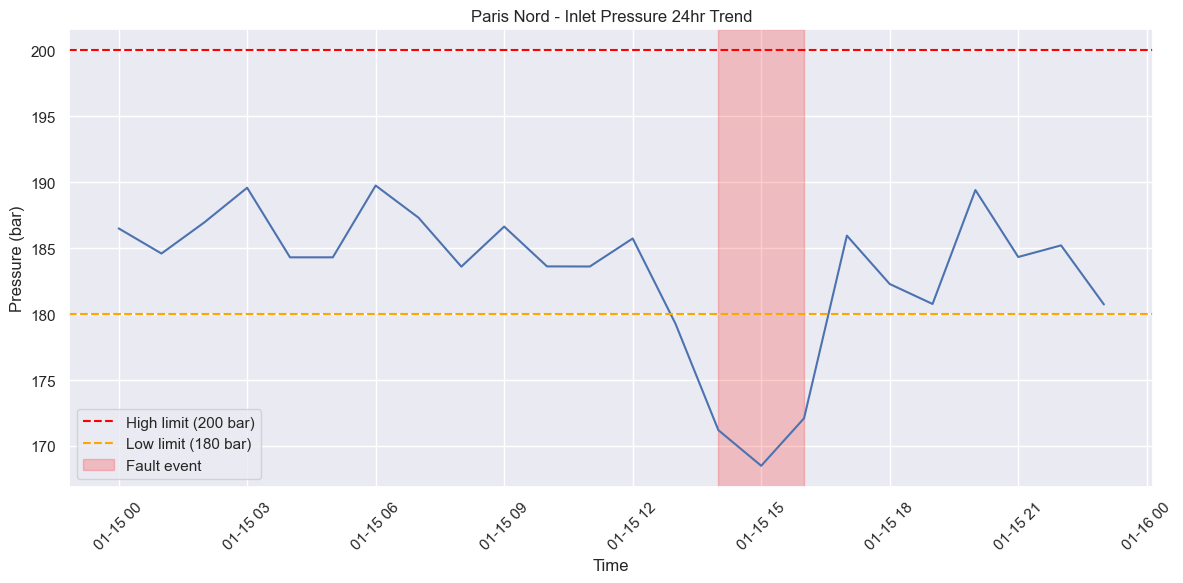

In [28]:
# Time series plot of Paris Nord pressure over 24 hours
plt.figure(figsize=(12, 6))
sns.lineplot(data=ts_df, x="timestamp", y="pressure")

# Alarm limits
plt.axhline(y=200, color="red", linestyle="--", label="High limit (200 bar)")
plt.axhline(y=180, color="orange", linestyle="--", label="Low limit (180 bar)")

# Shade the alarm region
plt.axvspan(ts_df["timestamp"][14], ts_df["timestamp"][16], 
            alpha=0.2, color="red", label="Fault event")

plt.title("Paris Nord - Inlet Pressure 24hr Trend")
plt.xlabel("Time")
plt.ylabel("Pressure (bar)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

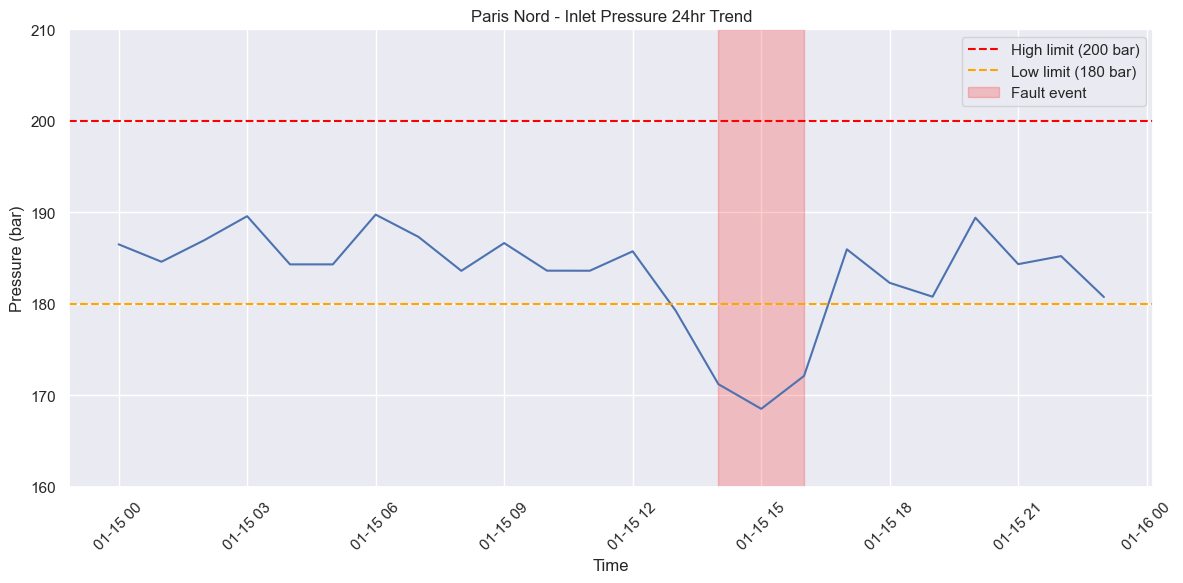

In [29]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=ts_df, x="timestamp", y="pressure")
plt.axhline(y=200, color="red", linestyle="--", label="High limit (200 bar)")
plt.axhline(y=180, color="orange", linestyle="--", label="Low limit (180 bar)")
plt.axvspan(ts_df["timestamp"][14], ts_df["timestamp"][16],
            alpha=0.2, color="red", label="Fault event")
plt.title("Paris Nord - Inlet Pressure 24hr Trend")
plt.xlabel("Time")
plt.ylabel("Pressure (bar)")
plt.ylim(160, 210)    # Fix the y axis range
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

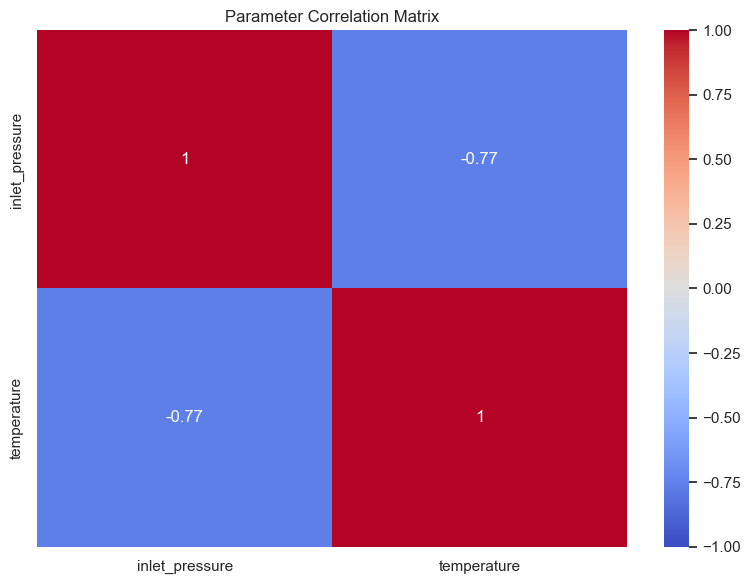

In [30]:
# Correlation heatmap across station parameters
plt.figure(figsize=(8, 6))

# Select only numeric columns
numeric_df = df[["inlet_pressure", "temperature"]]

# Calculate correlation matrix
correlation = numeric_df.corr()

sns.heatmap(correlation, annot=True, cmap="coolwarm", 
            vmin=-1, vmax=1, center=0)

plt.title("Parameter Correlation Matrix")
plt.tight_layout()
plt.show()

In [31]:
import numpy as np
import pandas as pd

np.random.seed(42)

# Generate 120 stations with realistic CNG operating parameters
n_stations = 120

# Ambient temperature varies by country
countries = (["France"] * 60 + ["Belgium"] * 30 + ["Netherlands"] * 30)
ambient_temps = {
    "France": 12,        # average annual ambient °C
    "Belgium": 10,
    "Netherlands": 9
}

stations = []
for i in range(n_stations):
    country = countries[i]
    ambient = ambient_temps[country]
    
    # Inlet pressure varies around 185 bar with some station variation
    pressure = np.random.normal(185, 8)
    
    # Temperature correlates with ambient + compressor heat
    # Higher pressure = more compression work = more heat (physically realistic)
    temperature = ambient + np.random.normal(30, 4) + (pressure - 185) * 0.3
    
    # Energy consumption correlates with pressure and temperature
    energy = np.random.normal(450, 30) + (pressure - 185) * 2

    stations.append({
        "station_id": i + 1,
        "country": country,
        "inlet_pressure": round(pressure, 1),
        "temperature": round(temperature, 1),
        "energy_kwh": round(energy, 1)
    })

big_df = pd.DataFrame(stations)
print(big_df.shape)
print(big_df.describe())

(120, 5)
       station_id  inlet_pressure  temperature  energy_kwh
count  120.000000       120.00000   120.000000  120.000000
mean    60.500000       185.70000    40.202500  454.636667
std     34.785054         6.43957     4.503415   33.165726
min      1.000000       169.40000    26.900000  370.800000
25%     30.750000       181.10000    37.000000  434.575000
50%     60.500000       186.60000    40.300000  453.150000
75%     90.250000       189.15000    43.325000  472.075000
max    120.000000       202.20000    50.500000  573.800000


In [32]:
np.random.seed(42)

n_stations = 120
countries = (["France"] * 60 + ["Belgium"] * 30 + ["Netherlands"] * 30)

ambient_temps = {
    "France": 12,
    "Belgium": 10,
    "Netherlands": 9
}

# Compressor sizes with realistic distribution across fleet
compressor_sizes = [45, 90, 160]
compressor_weights = [0.3, 0.5, 0.2]  # 30% small, 50% medium, 20% large

stations = []
for i in range(n_stations):
    country = countries[i]
    ambient = ambient_temps[country]
    
    # Assign compressor size
    compressor_kw = np.random.choice(compressor_sizes, p=compressor_weights)
    
    # Busier stations have bigger compressors
    # Map compressor size to daily run hours
    if compressor_kw == 45:
        daily_hours = np.random.uniform(2, 6)
    elif compressor_kw == 90:
        daily_hours = np.random.uniform(5, 12)
    else:  # 160kW
        daily_hours = np.random.uniform(10, 16)
    
    # Energy consumption
    energy_kwh = round(compressor_kw * daily_hours, 1)
    
    # Outlet pressure - similar across fleet, varies around 250 bar
    outlet_pressure = round(np.random.normal(250, 8), 1)
    outlet_pressure = max(200, min(280, outlet_pressure))  # clamp to realistic range
    
    # Outlet temperature - ambient + ~25 degrees, plus or minus 10
    outlet_temp = round(ambient + np.random.normal(25, 10), 1)
    outlet_temp = min(outlet_temp, 50)  # never exceeds 50 degrees
    
    stations.append({
        "station_id": i + 1,
        "country": country,
        "compressor_kw": compressor_kw,
        "daily_run_hours": round(daily_hours, 1),
        "outlet_pressure": outlet_pressure,
        "outlet_temperature": outlet_temp,
        "energy_kwh": energy_kwh
    })

big_df = pd.DataFrame(stations)
print(big_df.shape)
print(big_df.describe())

(120, 7)
       station_id  compressor_kw  daily_run_hours  outlet_pressure  \
count  120.000000     120.000000       120.000000       120.000000   
mean    60.500000      91.166667         8.225833       250.115000   
std     34.785054      43.674374         4.046588         7.914306   
min      1.000000      45.000000         2.100000       224.100000   
25%     30.750000      45.000000         5.200000       244.375000   
50%     60.500000      90.000000         7.200000       250.150000   
75%     90.250000      90.000000        11.300000       255.050000   
max    120.000000     160.000000        15.700000       268.500000   

       outlet_temperature   energy_kwh  
count            120.0000   120.000000  
mean              36.3175   909.924167  
std                8.2385   800.196689  
min               16.3000    94.400000  
25%               30.3500   232.875000  
50%               36.8000   644.950000  
75%               41.9500  1055.175000  
max               50.0000  2515.

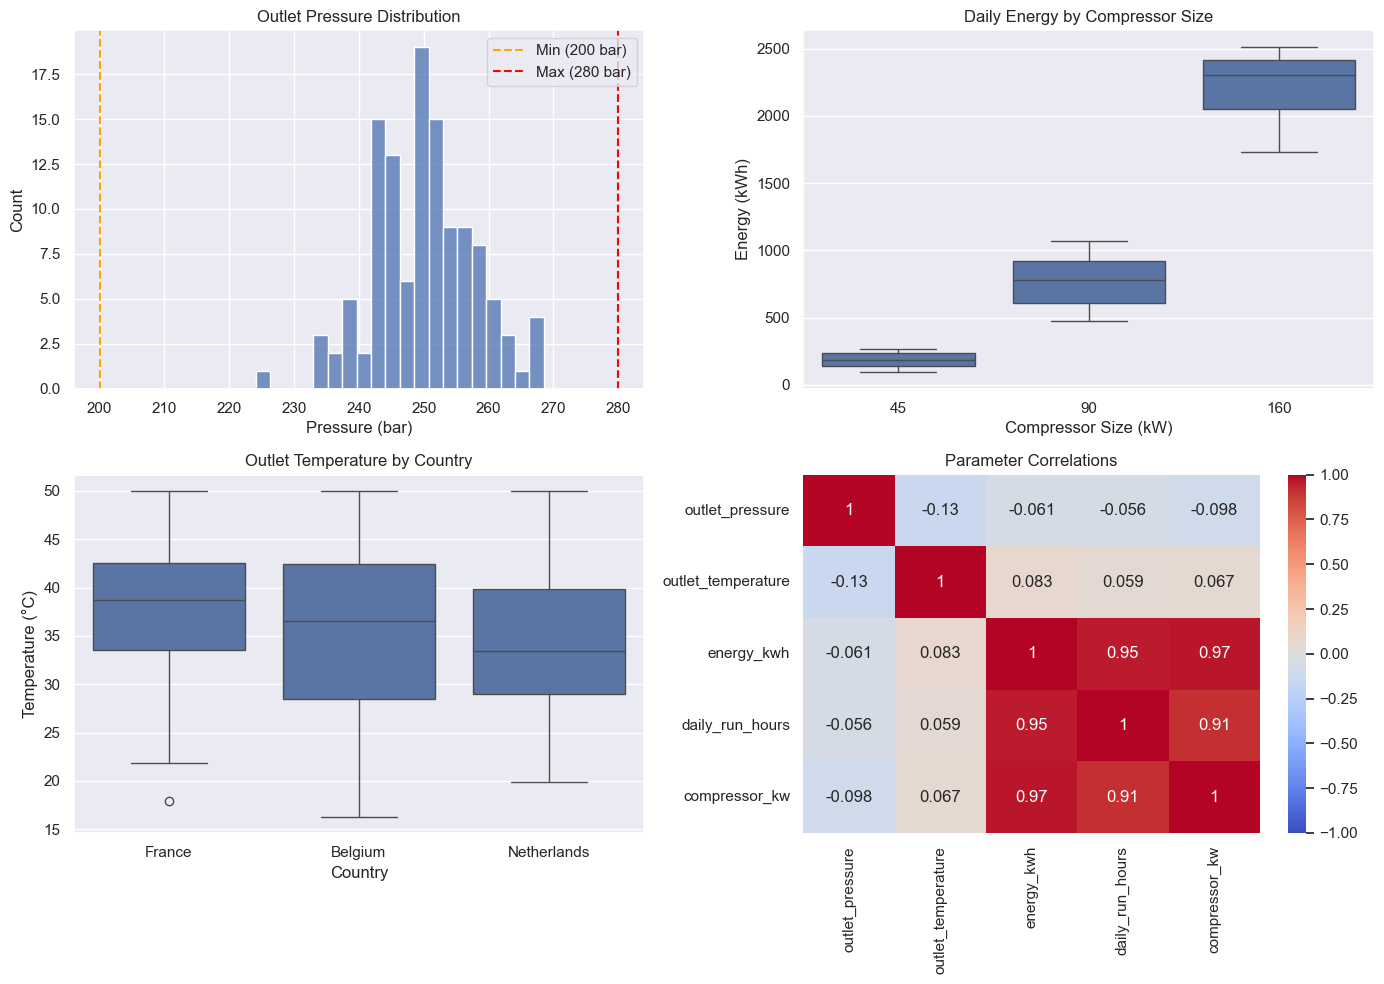

In [33]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# 1 - Outlet pressure distribution
sns.histplot(data=big_df, x="outlet_pressure", bins=20, ax=ax1)
ax1.axvline(x=200, color="orange", linestyle="--", label="Min (200 bar)")
ax1.axvline(x=280, color="red", linestyle="--", label="Max (280 bar)")
ax1.set_title("Outlet Pressure Distribution")
ax1.set_xlabel("Pressure (bar)")
ax1.legend()

# 2 - Energy by compressor size
sns.boxplot(data=big_df, x="compressor_kw", y="energy_kwh", ax=ax2)
ax2.set_title("Daily Energy by Compressor Size")
ax2.set_xlabel("Compressor Size (kW)")
ax2.set_ylabel("Energy (kWh)")

# 3 - Outlet temperature by country
sns.boxplot(data=big_df, x="country", y="outlet_temperature", ax=ax3)
ax3.set_title("Outlet Temperature by Country")
ax3.set_xlabel("Country")
ax3.set_ylabel("Temperature (°C)")

# 4 - Correlation heatmap
numeric_cols = big_df[["outlet_pressure", "outlet_temperature", 
                        "energy_kwh", "daily_run_hours", "compressor_kw"]]
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm",
            vmin=-1, vmax=1, center=0, ax=ax4)
ax4.set_title("Parameter Correlations")

plt.tight_layout()
plt.show()